# Домашнее задание: Alibaba Model Studio и вызов бесплатной VLM по `/chat/completions`

## Цель

Нужно самостоятельно пройти путь от регистрации в **Alibaba Cloud Model Studio** до успешного вызова мультимодальной модели через OpenAI-совместимый endpoint `/chat/completions`.[1][2]

Результат домашнего задания — рабочий минимальный клиент, который отправляет в модель **изображение + текстовый запрос** и получает содержательный ответ модели.[2]

## Что нужно освоить

После выполнения задания студент должен уметь:

- найти и активировать Model Studio;[1]
- получить API key и выбрать корректный региональный endpoint;[1]
- вызвать OpenAI-совместимый API через Python или `curl`;
- передать в `messages` мультимодальный запрос формата `image_url + text`;[2]
- понимать, какие модели в Model Studio подходят для visual understanding и какие из них доступны с бесплатной квотой для новых пользователей в Singapore region.[3][1]

## Постановка задачи

Нужно выбрать **любую бесплатную VLM-модель**, доступную в Alibaba Model Studio для новых пользователей, и сделать не менее **трёх** успешных запросов через `/chat/completions`.[3][4]

Один из запросов должен быть на **описание изображения**, один — на **извлечение структурированной информации**, и один — на **reasoning по изображению**.[2]

## Рекомендуемые бесплатные модели

Для новых пользователей в **Singapore region** Alibaba Model Studio предоставляет free quota на 90 дней после активации сервиса для ряда моделей.[1][5]

Ниже — хорошие варианты для этого ДЗ.

| Модель | Почему подходит | Что важно знать |
|---|---|---|
| `qwen3.5-plus` | Универсальная мультимодальная модель, поддерживает text/image/video input и OpenAI-compatible вызовы.[1][2] | Это самый безопасный выбор для первого запуска VLM в этом ДЗ.[2] |
| `qwen3.5-flash` | Более быстрая и более дешёвая мультимодальная модель для latency-sensitive сценариев.[1][2] | Подходит, если нужен быстрый отклик и простой пайплайн.[2] |
| `qwen3-vl-plus` | Специализированная VLM-линейка для visual understanding, object localization и multimodal agents.[2] | Хороший вариант, если хочется протестировать именно «классическую» VLM-семью Qwen-VL.[2] |
| `qwen3-vl-flash` | Более лёгкий и быстрый вариант Qwen3-VL.[2] | Удобен для экспериментов с визуальными задачами и reasoning.[2] |
| `qwen-vl-max` | Подходит для general visual tasks и фигурирует в документации как visual understanding model.[4][1] | Это модель предыдущего семейства; её можно взять для сравнения с более новыми моделями.[2] |
| `qwen-vl-plus` | Более дешёвый и быстрый вариант внутри Qwen2.5-VL family.[2] | Полезно сравнить с `qwen-vl-max` на простом VQA или OCR.[2] |

## Что именно нужно сделать

### Шаг 1. Зарегистрироваться и активировать сервис

1. Создайте или используйте существующий аккаунт Alibaba Cloud.
2. Откройте Model Studio и активируйте сервис.[1]
3. Выберите регион. Для нового пользователя наиболее полезен **Singapore region**, потому что именно там заявлена free quota для новых пользователей.[1][5]

### Шаг 2. Получить API key

Сгенерируйте API key для выбранного региона и сохраните его как переменную окружения `DASHSCOPE_API_KEY`.[2]

Пример для Linux/macOS:

```bash
export DASHSCOPE_API_KEY="sk-..."
```

Пример для Windows PowerShell:

```powershell
$env:DASHSCOPE_API_KEY="sk-..."
```

### Шаг 3. Выбрать endpoint

Model Studio поддерживает OpenAI-compatible API, но `base_url` зависит от региона.[1]

Основные варианты:

- Singapore: `https://dashscope-intl.aliyuncs.com/compatible-mode/v1`
- US (Virginia): `https://dashscope-us.aliyuncs.com/compatible-mode/v1`
- China (Beijing): `https://dashscope.aliyuncs.com/compatible-mode/v1`
- Hong Kong: `https://cn-hongkong.dashscope.aliyuncs.com/compatible-mode/v1`

Для этого ДЗ рекомендуется использовать именно **Singapore endpoint**.[1][2]

### Шаг 4. Сделать первый мультимодальный запрос

Нужно отправить в модель массив `content`, где один элемент — картинка, а второй — текстовый вопрос.[2]

Минимальный пример на Python:

```python
import os
from openai import OpenAI

client = OpenAI(
    # TODO
)

response = client.chat.completions.create(
    model="qwen3.5-plus",
    messages=[
          # TODO
    ]
)

print(response.choices[0].message.content)
```

Этот формат соответствует официальной документации Alibaba Cloud по visual understanding и OpenAI-compatible вызовам.[2]

Пример через `curl`:

```bash
curl --location '...' \
--header "..." \
--header '...' \
--data '{
  "model": "qwen3.5-plus",
  "messages": [
    # TODO
  ]
}'
```

## Обязательные эксперименты

Нужно сделать **три разных сценария**.

### Эксперимент A. Image captioning / VQA

Пример запроса:

```text
Кратко опиши изображение и перечисли 5 ключевых объектов сцены.
```

### Эксперимент B. Structured extraction

Нужно заставить модель вернуть структурированный ответ по изображению или документу.[2]

Пример запроса:

```text
Извлеки информацию с изображения и верни JSON со следующими полями: main_objects, scene_type, visible_text, colors.
```

### Эксперимент C. Visual reasoning

Нужно задать вопрос, где модель не просто перечисляет объекты, а делает вывод по изображению.[2]

Примеры:

```text
Что происходило непосредственно перед этим моментом и что вероятнее всего произойдет дальше? Объясни гипотезу.
```

```text
Есть ли на изображении признаки, указывающие на погоду, время суток или тип места? Обоснуй.
```

## Дополнительный уровень

Дополнительно можно протестировать:

- несколько изображений в одном запросе; это поддерживается документацией Model Studio для visual understanding.[2]
- streaming response; он поддерживается OpenAI-compatible API для chat completions.
- thinking mode для подходящих моделей семейства `qwen3.5` и `qwen3-vl`.[2]

Пример идеи для бонуса:

```text
Сравни два изображения и объясни, чем отличаются сцены, освещение и действия объектов.
```

## Что сдать

Нужно прислать один архив или одну папку со следующим содержимым:

1. `README.md` с кратким описанием, какую модель вы выбрали и почему.
2. `requirements.txt` или список используемых библиотек.
3. Скрипт `run_vlm.py` или `run_vlm.ipynb`.
4. Файл `report.md` с результатами экспериментов.
5. При желании — `curl_examples.txt`.

Либо

1. Заполненный jupyter notebook, содержащий информацию по всем предыдущим пунктам

## Требования к `report.md`

В отчёте обязательно должно быть:

- название выбранной модели;
- выбранный регион;
- какой endpoint использовался;
- какие именно запросы отправлялись;
- скриншоты или текст ответов модели;
- краткий анализ: где модель ответила хорошо, а где ошиблась или была слишком общей;
- оценка удобства Model Studio как платформы для быстрого старта.[1][2]

## Критерии оценивания

1. 8 баллов - основная часть задания
2. 2 балла - вы смогли настроить не только alibaba cloud, но нашли и задокументировали еще какого-то другого бесплатного (или условно-бесплатного) провайдера VLM моделей, а так же смогли его вызвать.

## Рекомендуемая структура решения

```text
project/
├── README.md
├── requirements.txt
├── run_vlm.py
├── report.md
└── assets/
    ├── test_image_1.jpg
    └── test_image_2.jpg
```

## Шаблон `report.md`

```markdown
# Отчёт по домашнему заданию: Alibaba Model Studio VLM

## 1. Выбранная модель
- Модель:
- Регион:
- Endpoint:
- Почему выбрана именно она:

## 2. Настройка окружения
- Версия Python:
- Библиотеки:
- Как задавался API key:

## 3. Эксперименты

### 3.1 Image captioning / VQA
**Запрос:**

**Ответ модели:**

**Комментарий:**

### 3.2 Structured extraction
**Запрос:**

**Ответ модели:**

**Комментарий:**

### 3.3 Visual reasoning
**Запрос:**

**Ответ модели:**

**Комментарий:**

## Минимальный `requirements.txt`

```text
openai>=1.0.0
```

## Подсказки

- Если получаете `401`, почти всегда проблема в API key или в том, что ключ создан не для того региона.
- Если получаете `429`, это может быть rate limit или исчерпание доступной квоты.
- Если модель не принимает картинку, проверьте, что вы передаёте `messages[].content` как список объектов, а не как одну строку.[2]
- Для первого запуска лучше брать `qwen3.5-plus`, потому что он явно документирован как мультимодальная модель с OpenAI-compatible вызовами.[1][2]


# Моя часть

Сама картинка
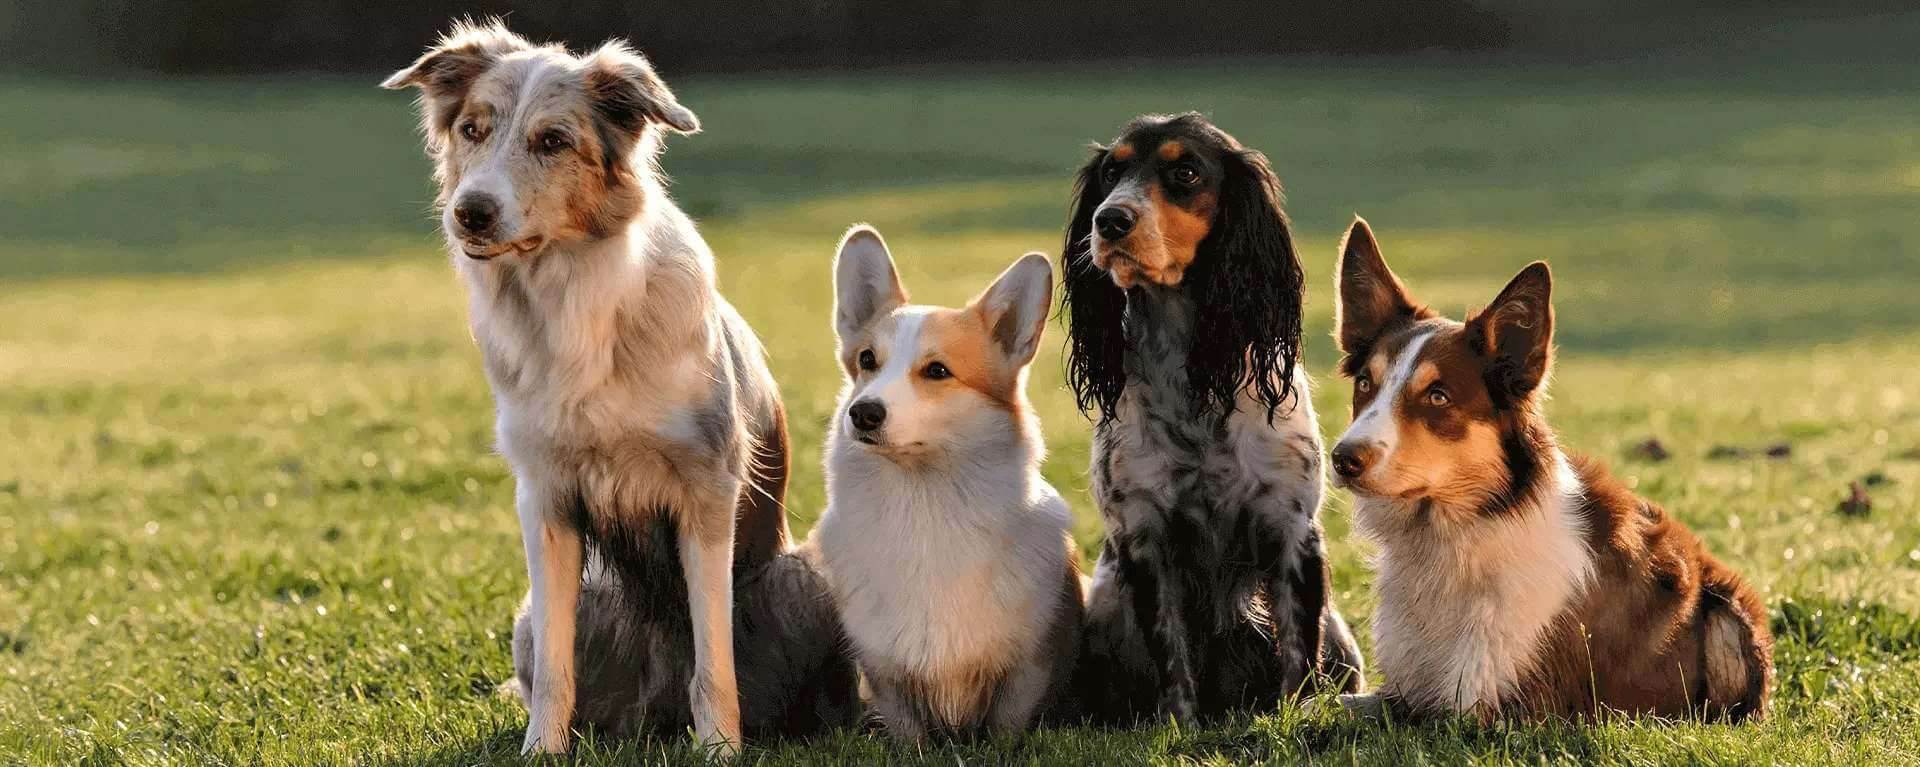

## A

In [7]:
import os
from openai import OpenAI

client = OpenAI(
    api_key=os.environ["DASHSCOPE_API_KEY"],          # vLLM принимает любой ключ
    base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1",
)

picture_with_dogs_url = "https://www.proplan.ru/sites/default/files/styles/image_1920x767/public/2023-08/perhot1920.jpg?itok=5YfEW_2s"

response = client.chat.completions.create(
    model="qwen3.5-plus",
    messages=[
          {
            "role": "user",
            "content": [
                {"type": "text", "text": "Сколько кошек на картинке?"},
                {
                    "type": "image_url",
                    "image_url": {"url": picture_with_dogs_url},
                },
            ],
        }
    ]
)

print(response.choices[0].message.content)

На этой картинке **нет кошек**.

На ней изображены четыре собаки разных пород (слева направо: похоже на австралийскую овчарку, вельш-корги, кокер-спаниель и бордер-колли).


In [8]:
response = client.chat.completions.create(
    model="qwen3.5-plus",
    messages=[
          {
            "role": "user",
            "content": [
                {"type": "text", "text": "Кратко опиши изображение и перечисли 5 ключевых объектов сцены."},
                {
                    "type": "image_url",
                    "image_url": {"url": picture_with_dogs_url},
                },
            ],
        }
    ]
)

print(response.choices[0].message.content)

**Описание изображения:**
На фотографии запечатлены четыре собаки разных пород, сидящие дружным рядом на зеленом газоне. Они смотрят в одну сторону (влево от зрителя), освещенные теплым солнечным светом, который создает мягкие тени. Фон размыт, что позволяет сфокусировать внимание на животных.

**5 ключевых объектов сцены:**
1.  **Собака слева:** Крупная собака с бело-серо-рыжей шерстью (похожа на австралийскую овчарку).
2.  **Вельш-корги:** Маленькая собака с большими стоячими ушами и бело-рыжей шерстью, сидящая второй слева.
3.  **Спаниель:** Собака с длинными висячими ушами и черно-белой пятнистой шерстью, сидящая третьей.
4.  **Собака справа:** Коричнево-белая собака с острыми ушами (похожа на бордер-колли), лежащая или сидящая с краю.
5.  **Зеленая трава:** Покрытие, на котором сидят животные, занимающее передний план.


## B

In [22]:
response = client.chat.completions.create(
    model="qwen3.5-plus",
    messages=[
          {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": "Просмотри картинку и верни ответ в следующем формате:\
                             json файл с {'num_cats':number of cats, 'num_dogs':number of dogs, 'num_birds':number of birds}."
                },
                {
                    "type": "image_url",
                    "image_url": {"url": picture_with_dogs_url},
                },
            ],
        }
    ]
)

print(response.choices[0].message.content)

```json
{
    "num_cats": 0,
    "num_dogs": 4,
    "num_birds": 0
}
```


## C

In [24]:
response = client.chat.completions.create(
    model="qwen3.5-plus",
    messages=[
          {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": "как ты думаешь, чем животные с картинки займутся далее?"
                },
                {
                    "type": "image_url",
                    "image_url": {"url": picture_with_dogs_url},
                },
            ],
        }
    ]
)

print(response.choices[0].message.content)

Судя по тому, как сосредоточенно все четверо смотрят в одну сторону (влево от нас), они явно чего-то ждут. Вот несколько вероятных сценариев того, что произойдет через пару секунд:

1.  **Рывок за добычей (или мячом).** Скорее всего, хозяин стоит перед ними и держит теннисный мяч, фрисби или палку. Как только предмет полетит, эта идиллическая картинка разрушится: все четыре собаки сорвутся с места и побегут ловить игрушку. Учитывая породы (тут есть пастушьи и спаниель), они очень азартные.

2.  **Получение награды.** Они могут ждать команду или просто лакомство. Если хозяин скажет «Можно!», они радостно подбегут, чтобы получить вкусняшку за то, что так хорошо позировали.

3.  **Начало «нюхательной» экскурсии.** Если фотография уже сделана и команда «Сидеть» отменена, они, скорее всего, начнут исследовать территорию. Спаниель и овчарки обожают искать запахи в траве.

4.  **Хаос.** Часто бывает так: стоит одному из них (например, корги посередине) дернуться или чихнуть, как остальные тож

## Streaming

In [33]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Какие породы собак на картинке?"},
            {"type": "image_url", "image_url": {"url": picture_with_dogs_url}},
        ],
    }
]

def chat_stream(messages, model="qwen-vl-plus"):
    print("Сообщение пользователя:")
    print(messages[-1]["content"][0]["text"])
    print("\n\n")
    stream = client.chat.completions.create(
        model=model,
        messages=messages,
        stream=True,
    )

    print("Ответ модели:")
    chunks = []
    for event in stream:
        if not event.choices:        # <-- вот это добавить
            continue
        delta = event.choices[0].delta
        piece = getattr(delta, "content", None)
        if piece:
            print(piece, end="", flush=True)
            chunks.append(piece)
    print("\n\n")
    return "".join(chunks)

answer = chat_stream(messages)
messages.append({"role": "assistant", "content": answer})


messages.append({"role": "user", "content": [{"type": "text", "text": "А какая из них охотничья?"}]})
answer = chat_stream(messages)
messages.append({"role": "assistant", "content": answer})


messages.append({"role": "user", "content": [{"type": "text", "text": "Какой был первый вопрос?"}]})
answer = chat_stream(messages)
messages.append({"role": "assistant", "content": answer})

Сообщение пользователя:
Какие породы собак на картинке?



Ответ модели:
На картинке изображены четыре собаки разных пород, сидящие на зеленой траве. Давайте рассмотрим каждую из них по порядку:

1. **Первая слева**: Это собака породы **Ауссурийский пастушья овчарка** (Australian Shepherd). Характерные признаки этой породы — разноцветная шерсть (в данном случае преимущественно белая с рыжими и серыми пятнами), уши в форме треугольника и выразительные глаза.

2. **Вторая слева**: Это собака породы **Корги Пемброк** (Welsh Corgi Pembroke). Отличительными чертами являются короткие лапы, длинная шерсть, большие стоячие уши и компактное телосложение.

3. **Третья слева**: Это собака породы **Спаниель** (например, Смоки-Спаниель или Бладхаунд). У неё длинная, волнистая шерсть, которая может быть черной, серой или смешанного цвета. Уши длинные и опущенные, что характерно для спаниелей.

4. **Справа**: Это собака породы **Бордер-колли** (Border Collie). Отличительные черты — густая шерсть, час

## thinking mode

In [34]:
response = client.chat.completions.create(
    model="qwen3.5-plus",
    messages=[
          {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": "как ты думаешь, чем животные с картинки займутся далее?"
                },
                {
                    "type": "image_url",
                    "image_url": {"url": picture_with_dogs_url},
                },
            ],
        }
    ],
    extra_body={
            "enable_thinking": True
        },
)

print(response.choices[0].message.content)

Судя по тому, как внимательно и дисциплинированно эти четверо смотрят в одну точку (вероятно, на хозяина или фотографа), можно предположить несколько сценариев того, что произойдет дальше:

1.  **Получат лакомство.** Это самый вероятный вариант. Они явно выполнили команду «сидеть» или «лежать» для красивого кадра. Как только фотограф скажет «Гуляй!» или щелкнет затвором в последний раз, скорее всего, последует команда «Молодец» и раздача вкусняшек.
2.  **Начнут бегать и играть.** На фото видно, что это активные породы (пастушьи собаки, корги, спаниель). Как только формальная часть с позированием закончится, их энергия вырвется наружу: они начнут гоняться друг за другом по траве или играть в мяч.
3.  **Побегут за кем-то.** Их взгляды сфокусированы. Возможно, они увидели белку, другую собаку или любимую игрушку, которую хозяин достал из кармана. В следующую секунду они могут сорваться с места в погоню.
4.  **Просто отдохнут.** Свет на фото мягкий, похоже на вечер. Возможно, после активно

In [44]:
print(response.choices[0].message.reasoning_content)

The user wants me to predict what the animals in the picture will do next.

1.  **Analyze the image:**
    *   **Subjects:** Four dogs.
        *   Left: Looks like an Australian Shepherd or Border Collie mix (merle coat). Sitting up, looking slightly left.
        *   Middle-left: A Corgi (Pembroke Welsh Corgi). Sitting, looking left.
        *   Middle-right: A spaniel type dog (maybe a Cocker Spaniel or similar mix with long ears). Sitting, looking slightly left/forward.
        *   Right: Another herding dog, looks like a Border Collie or Australian Shepherd (brown/white). Lying down, looking left.
    *   **Setting:** A grassy field, likely a park or backyard. The lighting suggests late afternoon or early evening ("golden hour").
    *   **Body Language:** They are all looking in roughly the same direction (to the left of the frame). They seem attentive, calm, and focused. They aren't playing right now; they are posing or waiting for a command. It looks like a staged photo.

2.  *

## Пара картинок

In [47]:
picture_backflip_cat_url = "https://lh6.googleusercontent.com/proxy/oVOlQLIH8McyiFVWofNFE4FvgfOlPFjTGrakUiBQNHBK5bcQReWMR6WnnJCiVmP-PiK9G8wwjQkIrxl4zG05vmelkQ0rx_mrm58"

Сама картинка: 
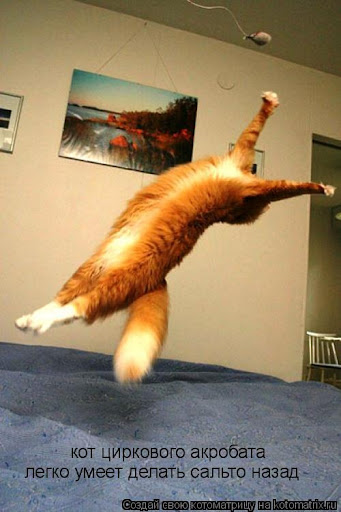

In [48]:
response = client.chat.completions.create(
    model="qwen3.5-plus",
    messages=[
          {
            "role": "user",
            "content": [
                {"type": "text", "text": "Сравни, на котором из фото животное делает сальто круче, назови животное, объясни свой выбор."},
                {"type": "image_url","image_url": {"url": picture_with_dogs_url}},
                {"type": "image_url","image_url": {"url": picture_backflip_cat_url}},
            ],
        }
    ]
)

print(response.choices[0].message.content)

На втором фото животное делает сальто круче, потому что на первом фото **никто не делает сальто**.

*   **Животное:** Это **кот** (рыжий кот).
*   **Объяснение:** На первой фотографии четыре собаки просто сидят на траве и позируют. На второй фотографии кот запечатлен в высоком прыжке с выгнутой спиной, а подпись под фото прямо утверждает, что он «умеет делать сальто назад». Поэтому кот — безоговорочный победитель в этой категории.


# Отчёт по домашнему заданию: Alibaba Model Studio VLM

## 1. Выбранная модель
- Модель: qwen3.5-plus
- Регион: Singapore
- Endpoint: Singapore: `https://dashscope-intl.aliyuncs.com/compatible-mode/v1`
- Почему выбрана именно она: Гигант подходящий для задач, требующих логических рассуждений.

## 2. Настройка окружения
- Версия Python: 3.13.12
- Библиотеки: os, openai v2.38.0
- Как задавался API key: через переменную окружения `DASHSCOPE_API_KEY`

## 3. Эксперименты

Всё в ноутбуке

## Минимальный `requirements.txt`

```text
openai>=2.38.0
python>=3.13.12